In [69]:
import cobra
import re
from pprint import pprint
import pandas as pd
import numpy as np
import copy
import os 
import sklearn 
import matplotlib.pyplot as plt

In [71]:

mitocore = cobra.io.read_sbml_model("/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/Mitocore_aligned_to_Human1.xml")
human1 = cobra.io.read_sbml_model("/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Input_Models/Human-GEM.xml")
#set directory and load models
os.mkdir('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Pathway_Coverage_Files')
os.chdir('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Pathway_Coverage_Files')

In [72]:
def sort_kegg_ids (model,target_db):
    """Extract reaction id for a target database from a defined model, if >1 id 
    add all ids as new entries.

    model: COBRApy model (not an .xml file but already loaded as a model)
    target_db: database key in the annotations of the model
    """
    import re
    pattern=r'R\d{5}' #Pattern KEGG ids recognition (e.g. R00209)

    kegg_react={'model_id':[], target_db:[]}

    #get reaction annotations from an object (loaded model)
    reactions= getattr(model , 'reactions')
    for reaction in reactions:
        target_id=reaction.annotation.get(target_db)

         # Normalize annotation value to string
        if isinstance(target_id, list):
            target_id = ' '.join(target_id)
        else:
            target_id = str(target_id)

        # Find all KEGG ids (e.g. R00209, R01324, etc.)
        matches = re.findall(pattern, target_id) #re.findall() works just with str
        for match in matches:
            kegg_react['model_id'].append(reaction.id)
            kegg_react[target_db].append(match)

    return pd.DataFrame.from_dict(kegg_react)

def kegg_API_req(model,input_df,input_id, target ,target_rest, split_pat):
    """ Function for API request to obtain KEGG module per reaction

    model: str, name of the model of interest
    input_df: dataframe with KEGG ids.
    target_db: target in KEGG to look for, position [0]. (e.g. 'kegg.module', 'kegg.reaction')
    target_rest: residue in the same line of target_db, position [1]. 
    split_pat: pattern to split when processing response. (e.g. 'PATHWAY', 'MODULE')
    """
    import pandas as pd
    import ssl  # certificates needed to access KEGG API 
    from urllib import request  

    output_dict = {'model_id': [], target: [], target_rest: []}
    ssl._create_default_https_context = ssl._create_unverified_context #create the certificate

    kegg_attr = list(input_df.loc[:,input_id])
    model_id = list(input_df.loc[:,'model_id'])


    batch_size = 10

    counter = 0

    for batch in range(0, len(kegg_attr), batch_size):

        url = 'https://rest.kegg.jp/get/'
        batch_index = 0
        batch_entries = []
        
        while(batch + batch_index < len(kegg_attr) and batch_index < batch_size):
            
            batch_entries.append(kegg_attr[batch + batch_index])
            url += kegg_attr[batch + batch_index]
            
            if batch_index < batch_size-1:
                url+='+'
            
            batch_index += 1

        req = request.Request(url)
        with request.urlopen(req) as f:
            response = f.read()
        response_string_list = response.decode('utf-8').splitlines()

        reading_pathway_section = False
        gene_has_pathways = False

        entry_index = 0

        for line in response_string_list:

            if line == '///':
                if not gene_has_pathways:
                    output_dict['model_id'].append(model_id[counter])
                    output_dict[target].append('')
                    output_dict[target_rest].append('')

                print('attr:', counter + 1, 'of', len(kegg_attr), end='\r')

                entry_index += 1
                counter += 1
                reading_pathway_section = False
                gene_has_pathways = False
                continue
            
            if reading_pathway_section and not line.startswith(' '):
                reading_pathway_section = False

            if line.startswith(split_pat):
                reading_pathway_section = True
                gene_has_pathways = True
                line = line.split(split_pat)[1]
            
            if reading_pathway_section:
                line_split = line.strip().split('  ')

                output_dict['model_id'].append(model_id[counter])
                output_dict[target].append(line_split[0])
                output_dict[target_rest].append(line_split[1])

        
        
    return pd.DataFrame.from_dict(output_dict).to_csv(f"{target}_{model}.csv", index=False)

def sort_kegg_ids_human1 (model,target_db ):
    """Extract reaction id for a target database from human1, if >1 id 
    add all ids as new entries.

    -model: COBRApy model 
    -target_db: database key in the annotations of the model
    """
    import re
    pattern=r'R\d{5}'

    kegg_react={'model_id':[], target_db:[]}

    reactions= getattr(model , 'reactions')
    for ann in reactions:
        #human1_c_e_m is a list with all reactions in compartments c,e,m 
        if ann in human1_c_e_m: 
            target_id=ann.annotation.get(target_db)

            # Normalize annotation value to string
            if isinstance(target_id, list):
                target_id = ' '.join(target_id)
            else:
                target_id = str(target_id)

            # Find all KEGG IDs (e.g., R00209, R01324, etc.)
            matches = re.findall(pattern, target_id) #re.findall() works just with str
            for match in matches:
                kegg_react['model_id'].append(ann.id)
                kegg_react[target_db].append(match)

    return pd.DataFrame.from_dict(kegg_react)

def extract_modules(modes_model1,modes_model2):
    """function to extract all the modules for 2 models.

    -modes_model1: .csv file with modes from model 1.
    -modes_model2: .csv file with modes from model 2

    returns: dataframe with all modules from both models (2 columns: module id, module name)
    """

    modules_total={'module':[], 'module name':[]}
    for index, row in modes_model1.iterrows():
        module= row['kegg.module']
        name= row['module_name']

        if pd.notna(module):
            modules_total['module'].append(module)
            modules_total['module name'].append(name)

    for index, row in modes_model2.iterrows():
        module= row['kegg.module']
        name= row['module_name']

        if pd.notna(module):
            modules_total['module'].append(module)
            modules_total['module name'].append(name)

    return pd.DataFrame(modules_total)

def kegg_API_modul_content(input_df, input_id, target):
    """ Function to perform KEGG API request to obtain all KEGG reactions contained in a KEGG module
   
    -input_df: dataframe with KEGG module ids.
    -target_db: name of column with modules in input_df
    -target: target (whole reaction response per module)

    returns: dataframe with all reactions per module (2 columns: module id, whole content of the module (reactions, compounds, enzymes))
    """
    
    import pandas as pd
    import ssl
    from urllib import request

    ssl._create_default_https_context = ssl._create_unverified_context

    output_dict = {'module_id': [], target: []}

    kegg_attr = list(input_df[input_id])
    batch_size = 10

    for batch in range(0, len(kegg_attr), batch_size):

        batch = kegg_attr[batch:batch + batch_size]
        url = "https://rest.kegg.jp/get/" + "+".join(batch)

        with request.urlopen(url) as f:
            lines = f.read().decode("utf-8").splitlines()

        #flags and collecting list
        current_module = None
        is_hsa = False
        collecting_reactions = False
        reaction_buffer = []

        for line in lines:

            # start a new module from batch 
            if line.startswith("ENTRY"):
                # reset state for new module
                current_module = line.split()[1] # extract module id from line: (ENTRY       M00155            Pathway)
                is_hsa = False
                collecting_reactions = False
                reaction_buffer = []

            # check if module is human from line: (COMPLETE    hsa  Homo sapiens (human))
            elif line.startswith("COMPLETE"):
                if "hsa" in line:
                    is_hsa = True

            # start reaction collection only if module is human
            elif line.startswith("REACTION") and is_hsa:
                 # collect continuation lines
                collecting_reactions = True
                reaction_buffer = [line[len("REACTION"):].strip()]

            # stop when a new block starts 
            elif collecting_reactions:
                if line.startswith(("COMPOUND", "ENZYME", "NAME", "ENTRY", "CLASS", "DEFINITION", "PATHWAY", "MODULE", "ORTHOLOGY", "REFERENCE", "COMMENT")):
                    collecting_reactions = False
                else:
                    reaction_buffer.append(line.strip())

            # end of module
            # write only if human
            if line == "///":
                if is_hsa:
                    result = " ".join(reaction_buffer).strip()
                    output_dict["module_id"].append(current_module)
                    output_dict[target].append(result)

                # reset for next module
                current_module = None
                is_hsa = False
                collecting_reactions = False
                reaction_buffer = []

    df = pd.DataFrame(output_dict)
    df.to_csv("modules_content_hsa.csv", index=False)
    return df

def module_coverage_index(reactions_mod, dict_with_modules_react, csv_modules_model):
    """ function to calculate the coverage index of a model based on KEGG modules

    -reactions_mod: dataframe with all reactions in the model and the reactions KEGG ids
    -dict_with_modules_react: dictionary with all modules as key and all reactions of the module as values
         dict {'M00549': ['R01786, R02189, R00959, R00289']}
    -csv_modules_model: csv file with all modules in the model 

    returns: dataframe with coverage index per module (2 columns: module id, coverage index)
    """
    import re
    
    modules_model= pd.read_csv(csv_modules_model)
    
    # avoid duplicate module ids from the csv file 
    modules_model_ids = list(modules_model['kegg.module'].unique())

    # discard duplicates from the reactions list
    reactions = list(set(reactions_mod['kegg.reaction']))
    modules = dict_with_modules_react
    #open collecting dict
    coverage_dict = { 'module id': [], 'module name': [], 'coverage': []}

    # loop over modules in list of modules from the model
    for module_id in modules_model_ids:
        # check if module is in mapping dict
        if module_id in modules:

            name_series = modules_model.loc[modules_model['kegg.module'] == module_id, 'module_name']
            name = name_series.values[0] if len(name_series) > 0 else 'Unknown'
            # normalize stored value into a list of R00000 ids
            raw = modules[module_id]
            if isinstance(raw, str):
                react_in_module = re.findall(r'R\d{5}', raw)
            elif isinstance(raw, (list, tuple)):
                # join then extract (handles list of one id or list of ids as str)
                joined = " ".join(str(x) for x in raw)
                react_in_module = re.findall(r'R\d{5}', joined)
            else:
                # make a list out of it
                try:
                    react_in_module = list(raw)
                except Exception:
                    react_in_module = []
            #calculate total number of reactions in a module 100%
            total_react_in_module = len(react_in_module)
            print(f"module {module_id} has {total_react_in_module} reactions")
            # handle cases of empty modules
            if total_react_in_module == 0:
                coverage_dict['module id'].append(module_id)
                coverage_dict['module name'].append(name)
                coverage_dict['coverage'].append(0)
                continue
            # count how many reactions from the module are in the model
            react_set = set(react_in_module)
            counter = sum(1 for reaction in reactions if reaction in react_set)
            coverage = counter / total_react_in_module

            # store coverage ratio once per module
            coverage_dict['module id'].append(module_id)
            coverage_dict['module name'].append(name)
            coverage_dict['coverage'].append(coverage)
            
    return pd.DataFrame(coverage_dict)

# Processing Mitocore reactions to extract KEGG modules
1. Extract KEGG ids from Mitoocore and Mitocore ids into dataframe
2. Api request to obtain KEGG modules for this KEGG ids


In [73]:
# Processing Mitocore KEGG ids calling functions
kegg_mito=sort_kegg_ids(mitocore,'kegg.reaction')
print('lenght: ', len(kegg_mito))
#pd.DataFrame(kegg_mito).to_csv('kegg_reactions_mito.csv')

# API calling function
kegg_API_req('mitocore', kegg_mito,'kegg.reaction', 'kegg.module','module_name', 'MODULE')



lenght:  367


# Processing Human1 reactions

1. Extract just reactions from (Cytosol, Extracelular,Mitochondria) to make Human1 comparable to Mitocore
2. KEGG ids from Mitoocore and Mitocore ids into dataframe
3. API request to obtain KEGG modules for this KEGG ids and save into csv



In [74]:
# 1.Extract just reactions from c,e,m compartments)
allowed = {'c', 'm', 'e', 'i'}
human1_c_e_m = [ 
    reaction for reaction in human1.reactions
    if {met.compartment for met in reaction.metabolites}.issubset(allowed)
]
print(len(human1_c_e_m))

9673


In [75]:
# KEGG ids from Mitoocore and Mitocore ids into dataframe
kegg_human1=sort_kegg_ids_human1 (human1,'kegg.reaction')
print('lenght: ', len(kegg_mito))

df_human1 = kegg_human1[kegg_human1['kegg.reaction'].notna()]
print('lenght: ', len(kegg_human1))



lenght:  367
lenght:  1855


In [76]:
# API request to obtain KEGG modules for this KEGG ids
#pd.DataFrame(df_human1).to_csv('kegg_reactions_human1.csv')
kegg_API_req('human1',df_human1,'kegg.reaction', 'kegg.module','module_name', 'MODULE')

# Filter human modules 
1. read modules MitoCore and Human1
2. unite into one unique KEGG modules dataframe 
3. extract modules from dataframe into list for API request
4. API request for KEGG module content (just human modules)
5. create mapping dictionary (just human modules)
5. filter just human modules from datafram in 3. with mapping df in 5. 

In [77]:
# 1.  read modules for Mitocore and Human1 from API request 
modules_mito= pd.read_csv('kegg.module_mitocore.csv')
modules_human1= pd.read_csv('kegg.module_human1.csv')

# 2. Unique KEGG modules Mitocore, Human1 drop duplicates
total_modules= extract_modules(modules_mito,modules_human1)
total_modules= total_modules.drop_duplicates()

#check the modules that are not present in Human1 to extract their reactions 
total_modules.to_csv('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Pathway_Coverage_Files/total_modules.csv', index=False)
print(len(total_modules))

# 3. extract modules into a list for API request of module content
modules_total = list(total_modules['module'])
modules_total_df = pd.DataFrame(modules_total, columns=['module'])
print(modules_total_df)

228
     module
0    M00001
1    M00549
2    M00002
3    M00003
4    M00165
..      ...
223  M00898
224  M00124
225  M00103
226  M00538
227  M01047

[228 rows x 1 columns]


In [78]:
# 4. API request for KEGG modules
Modules_response=kegg_API_modul_content(modules_total_df, 'module', 'reactions')

In [79]:
# 5. Create dictionary with strcture
#  {'M00549': ['R01786, R02189'], 'M00002': ['R01015, R07159']}
module_reactions = pd.read_csv('modules_content_hsa.csv') 

import re
pattern = r'R\d{5}'  # Pattern KEGG ids recognition (e.g. R00209)
modules_dict = {}

for index, row in module_reactions.iterrows():
    module = row['module_id']
    reactions = str(row['reactions'])  # Convert reactions to string
    matches = re.findall(pattern, reactions)  # re.findall() works just with str
    if matches:
        if module not in modules_dict:
            modules_dict[module] = []  # Initialize the list for the module
        modules_dict[module].append(', '.join(matches))  # Join matches into a single string

print(modules_dict)

{'M00001': ['R01786, R02189, R09085, R13199, R00756, R05805, R01068, R01015, R01061, R01063, R01512, R07159, R01518, R00658, R00200'], 'M00549': ['R01786, R02189, R00959, R00289'], 'M00002': ['R01015, R01061, R01063, R01512, R07159, R01518, R00658, R00200'], 'M00003': ['R00431, R00726, R00341, R00658, R01518, R01512, R01061, R01063, R01015, R01068, R00762'], 'M00004': ['R02736, R10907, R02035, R01528, R10221, R01529, R01056, R01641, R08575, R01067, R13199, R02739'], 'M00006': ['R02736, R10907, R02035, R01528, R10221'], 'M00007': ['R01067, R08575, R01641, R01529, R01056'], 'M00307': ['R00209, R01196, R10866, R00014, R03270, R02569, R07618'], 'M00009': ['R00351, R01325, R01900, R01324, R01899, R00268, R00267, R00709, R00621, R03316, R01700, R02570, R07618, R01197, R00405, R00432, R00727, R10343, R02164, R01082, R00342, R00361'], 'M00011': ['R00621, R03316, R01700, R02570, R07618, R01197, R00405, R00432, R00727, R10343, R02164, R01082, R00342, R00361'], 'M00032': ['R00716, R02313, R03102,

In [80]:
# 1. calculate coverage index
modules_mito=module_coverage_index(kegg_mito, modules_dict, 'kegg.module_mitocore.csv' )
modules_hum=module_coverage_index(df_human1, modules_dict, 'kegg.module_human1.csv' )

modules_mito = modules_mito.rename(columns={'coverage': 'Mitocore'})
modules_hum = modules_hum.rename(columns={'coverage': 'Human1'})

# Merge on module id, keep all modules from both models
df_combined = pd.merge( modules_hum[['module id', 'module name', 'Human1']], modules_mito[['module id','module name', 'Mitocore']], on='module name', how='outer' )

# Optional: set module name as index for plotting
df_combined = df_combined.set_index('module name')
df_combined=df_combined.sort_index(axis=0)

print('lenght:', len(df_combined), df_combined)

module M00001 has 15 reactions
module M00549 has 4 reactions
module M00002 has 8 reactions
module M00003 has 11 reactions
module M00004 has 12 reactions
module M00006 has 5 reactions
module M00007 has 5 reactions
module M00307 has 7 reactions
module M00009 has 22 reactions
module M00011 has 14 reactions
module M00032 has 14 reactions
module M00036 has 9 reactions
module M00010 has 8 reactions
module M00152 has 1 reactions
module M00154 has 1 reactions
module M00158 has 1 reactions
module M00160 has 1 reactions
module M00050 has 5 reactions
module M00049 has 5 reactions
module M00086 has 1 reactions
module M00087 has 28 reactions
module M00085 has 28 reactions
module M00095 has 7 reactions
module M00082 has 5 reactions
module M00083 has 35 reactions
module M00741 has 3 reactions
module M00034 has 14 reactions
module M00035 has 5 reactions
module M00338 has 2 reactions
module M00038 has 7 reactions
module M00912 has 10 reactions
module M00970 has 4 reactions
module M00972 has 5 reactions

/var/folders/9p/_1828r2n5gb11k82139j3hz00000gn/T/ipykernel_2205/1558694639.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1000x800 with 0 Axes>

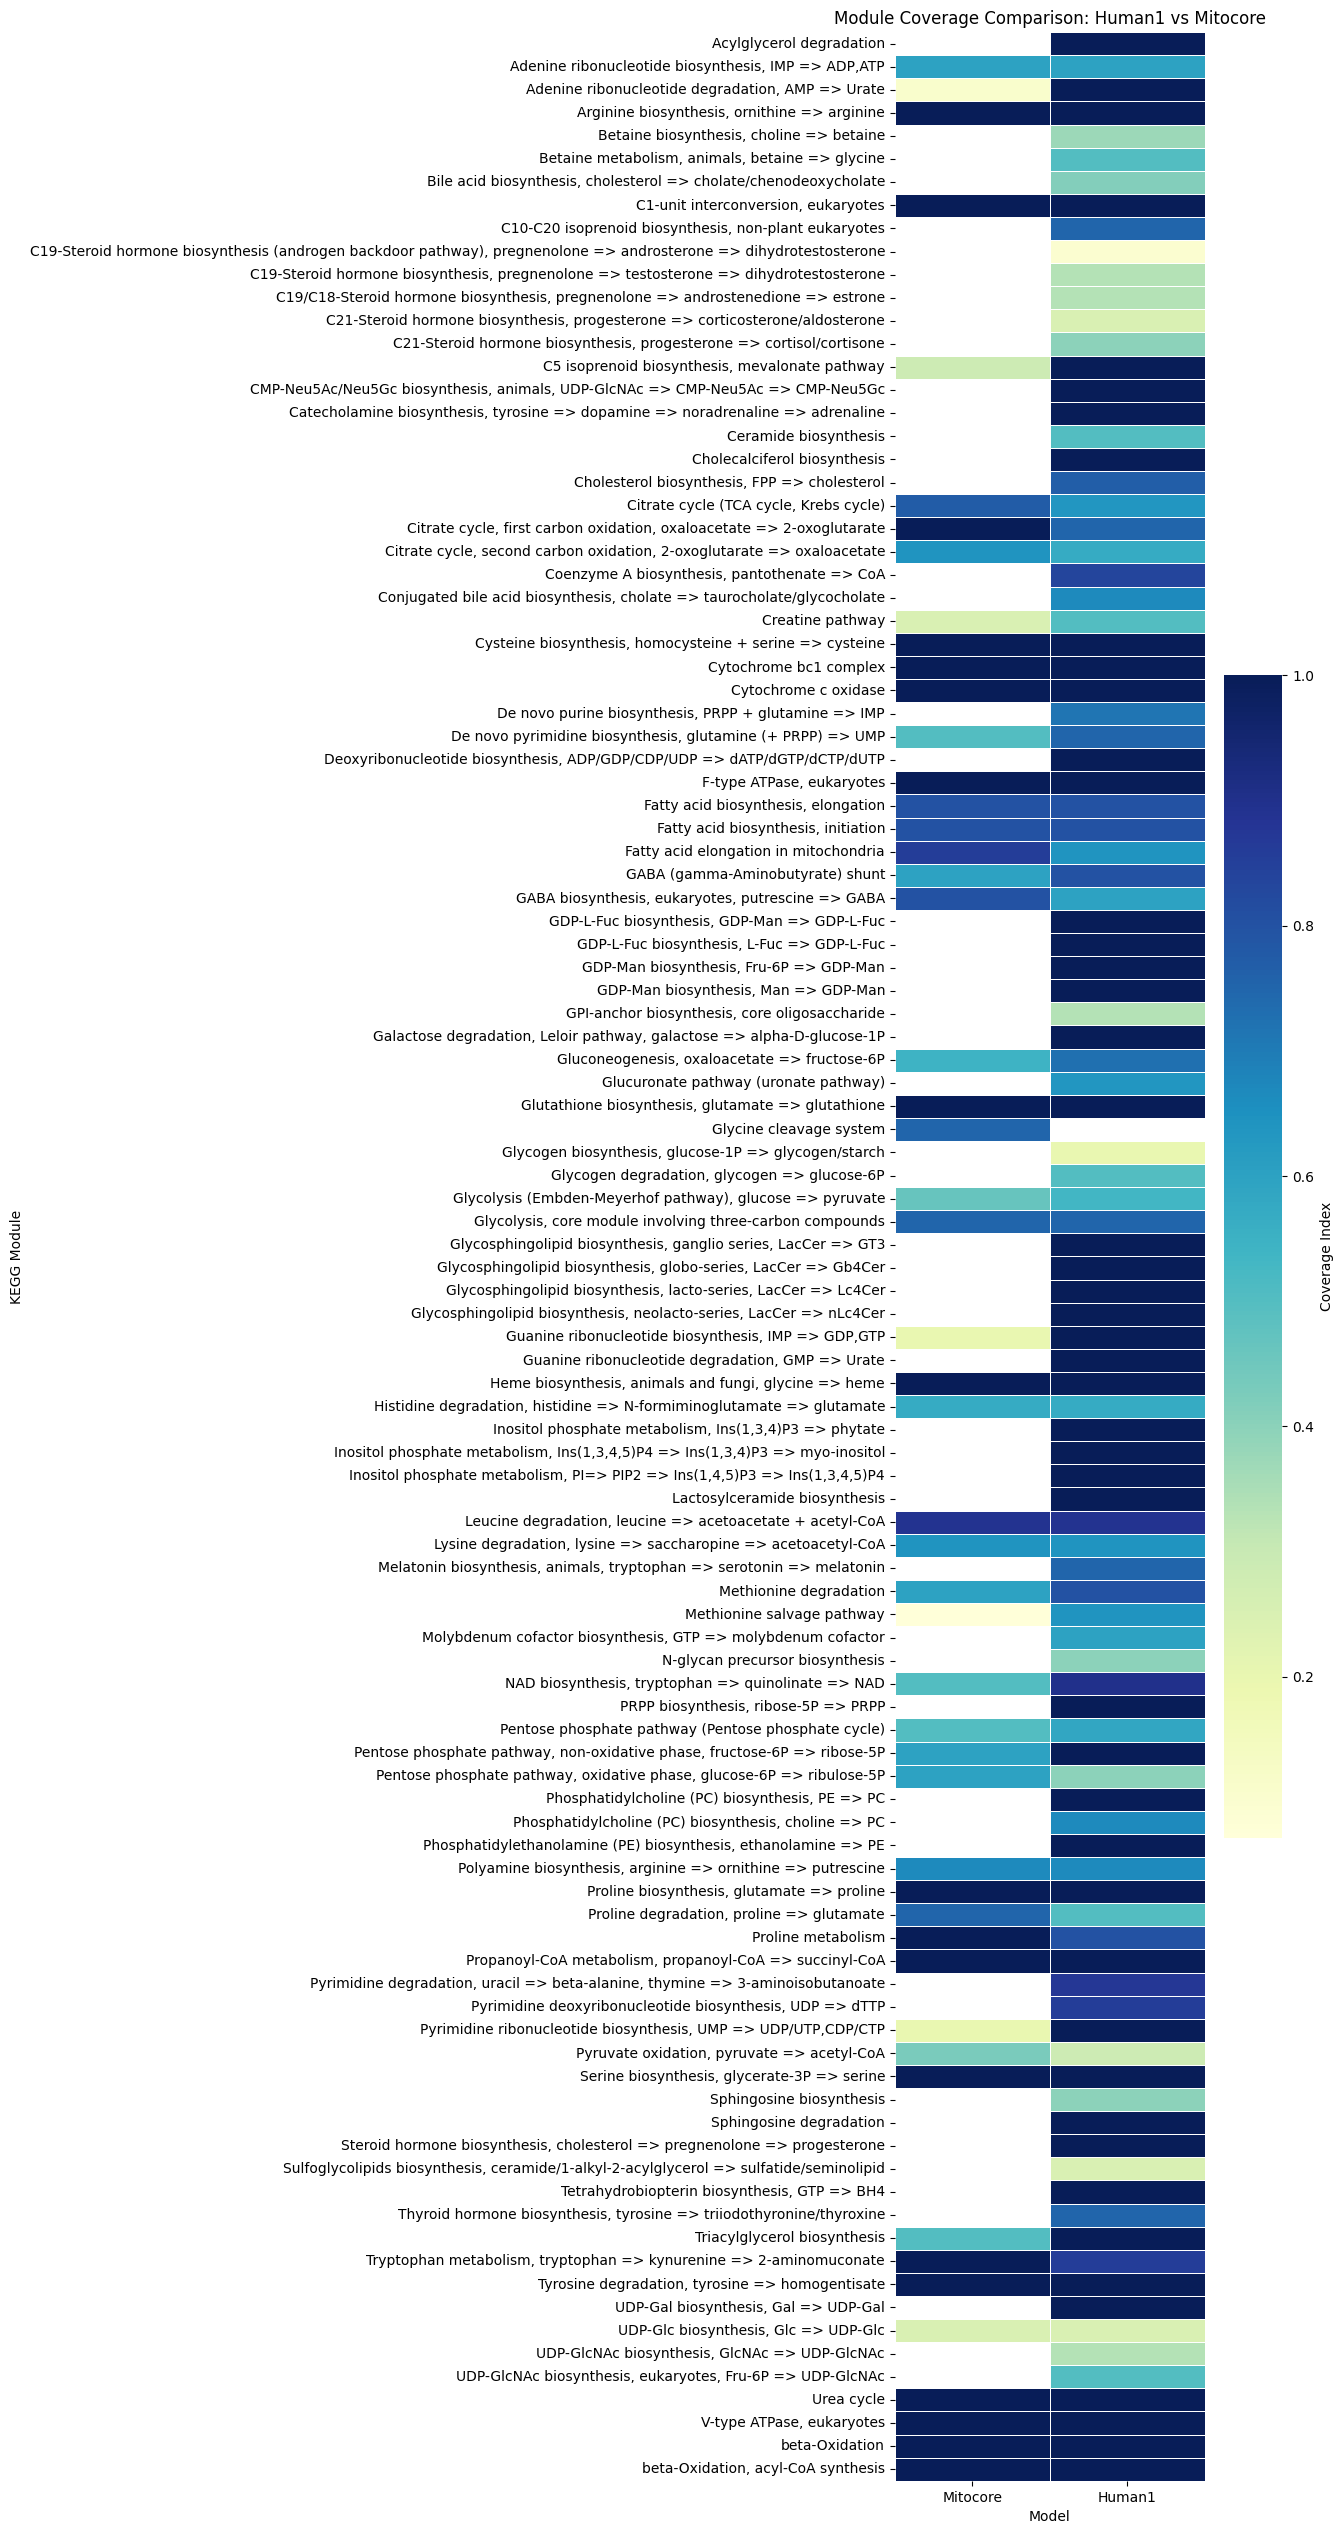

<Figure size 640x480 with 0 Axes>

In [82]:
# 2. Plot coverage index
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Select only numerical columns for the heatmap
heatmap_data = df_combined[['Mitocore', 'Human1']]

plt.figure(figsize=(5, len(heatmap_data) * 0.3)) # Adjust height to number of modules
sns.heatmap(
    heatmap_data,
    annot=False,  # show numbers inside cells
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Coverage Index'}
)
plt.title("Module Coverage Comparison: Human1 vs Mitocore")
plt.ylabel("KEGG Module")
plt.xlabel("Model")
plt.tight_layout()
plt.show()
plt.savefig("/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Pathway_Coverage_Files/Pathway_Coverage_Total.png", dpi=300)

# Plot just with Human1 Modules

In [83]:
# 1. calculate coverage index
modules_mito=module_coverage_index(kegg_mito, modules_dict, 'kegg.module_mitocore.csv' )
modules_hum=module_coverage_index(df_human1, modules_dict, 'kegg.module_human1.csv' )

modules_mito = modules_mito.rename(columns={'coverage': 'Mitocore'})
modules_hum = modules_hum.rename(columns={'coverage': 'Human1'})

# Filter Human1 modules to those present in Mitocore
# modules_hum already contains coverage for Human1, indexed by 'module id' and 'module name'
filtered_human1 = modules_hum[modules_hum['module id'].isin(modules_mito['module id'])]
print(filtered_human1)



module M00001 has 15 reactions
module M00549 has 4 reactions
module M00002 has 8 reactions
module M00003 has 11 reactions
module M00004 has 12 reactions
module M00006 has 5 reactions
module M00007 has 5 reactions
module M00307 has 7 reactions
module M00009 has 22 reactions
module M00011 has 14 reactions
module M00032 has 14 reactions
module M00036 has 9 reactions
module M00010 has 8 reactions
module M00152 has 1 reactions
module M00154 has 1 reactions
module M00158 has 1 reactions
module M00160 has 1 reactions
module M00050 has 5 reactions
module M00049 has 5 reactions
module M00086 has 1 reactions
module M00087 has 28 reactions
module M00085 has 28 reactions
module M00095 has 7 reactions
module M00082 has 5 reactions
module M00083 has 35 reactions
module M00741 has 3 reactions
module M00034 has 14 reactions
module M00035 has 5 reactions
module M00338 has 2 reactions
module M00038 has 7 reactions
module M00912 has 10 reactions
module M00970 has 4 reactions
module M00972 has 5 reactions

In [84]:
# Merge on module id, keep all modules from both models
df_combined = pd.merge( filtered_human1[['module id', 'module name', 'Human1']], modules_mito[['module id','module name', 'Mitocore']], on='module name', how='outer' )

# Optional: set module name as index for plotting
df_combined = df_combined.set_index('module name')
df_combined=df_combined.sort_index(axis=0)

print('lenght:', len(df_combined), df_combined)

lenght: 51                                                    module id_x    Human1  \
module name                                                                
Adenine ribonucleotide biosynthesis, IMP => ADP...      M00049  0.600000   
Adenine ribonucleotide degradation, AMP => Urate        M00958  1.000000   
Arginine biosynthesis, ornithine => arginine            M00844  1.000000   
C1-unit interconversion, eukaryotes                     M00141  1.000000   
C5 isoprenoid biosynthesis, mevalonate pathway          M00095  1.000000   
Citrate cycle (TCA cycle, Krebs cycle)                  M00009  0.636364   
Citrate cycle, first carbon oxidation, oxaloace...      M00010  0.750000   
Citrate cycle, second carbon oxidation, 2-oxogl...      M00011  0.571429   
Creatine pathway                                        M00047  0.500000   
Cysteine biosynthesis, homocysteine + serine =>...      M00338  1.000000   
Cytochrome bc1 complex                                  M00152  1.000000   
C

/var/folders/9p/_1828r2n5gb11k82139j3hz00000gn/T/ipykernel_2205/3037058221.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1000x800 with 0 Axes>

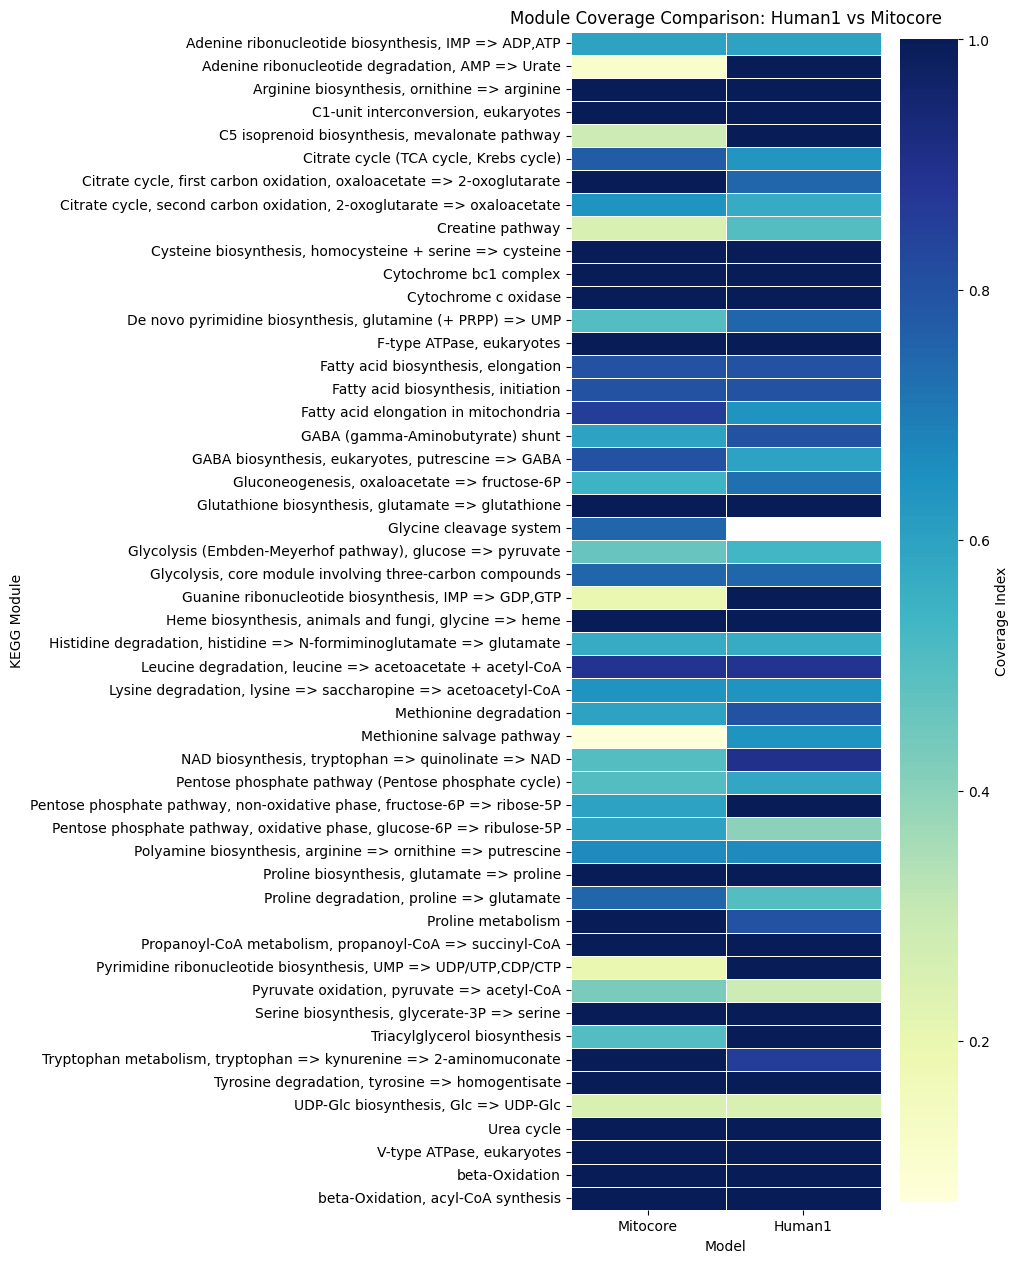

In [85]:
# 2. Plot coverage index
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Select only numerical columns for the heatmap
heatmap_data = df_combined[['Mitocore', 'Human1']]

plt.figure(figsize=(5, len(heatmap_data) * 0.3)) # Adjust height to number of modules
sns.heatmap(
    heatmap_data,
    annot=False,  # show numbers inside cells
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Coverage Index'}
)
plt.title("Module Coverage Comparison: Human1 vs Mitocore")
plt.ylabel("KEGG Module")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# Check modules not present in Human1 manually

In [ ]:
for key, val in modules_dict.items():
    if key in ['M00152', 'M00154', 'M00621', 'M00158' ]: #M00158 is a check module for the ATP-eucariotes
        print(key, val)

M00152 ['R02161']
M00154 ['R00081']
M00158 ['R00086']
M00621 ['R03425, R04125, R03815, R01221']


In [ ]:
for reaction in human1.reactions:
    annotations= reaction.annotation
    kegg= annotations.get('kegg.reaction')
    if kegg in ['R02161', 'R00081', 'R03425', 'R04125', 'R03815', 'R01221','R00086']: #R00086 is a check module for the ATP-eucariotes
        print('human1 id:', reaction.id, 'Kegg reaction:', annotations['kegg.reaction'])

human1 id: MAR06914 Kegg reaction: R00081
human1 id: MAR06916 Kegg reaction: R00086
human1 id: MAR06918 Kegg reaction: R02161
human1 id: MAR03964 Kegg reaction: R00086


In [ ]:
df_human1.to_csv('kegg_reactions_human1.csv', index=False)

In [ ]:
for react in human1.reactions:
    kegg = react.annotation.get('kegg.reaction')
    if kegg in ['R02161', 'R00081']:
        print('human1 id:', react.id, react)
        metabolites = react.metabolites
        for met in metabolites:
            print(met.compartment, met.id)


human1 id: MAR06914 MAR06914: 4.0 MAM01826m + 8.0 MAM02039m + MAM02630m --> 4.0 MAM01824m + 4.0 MAM02039i + 2.0 MAM02040m
m MAM01826m
m MAM02039m
m MAM02630m
m MAM01824m
m MAM02040m
i MAM02039i
human1 id: MAR06918 MAR06918: 2.0 MAM01824m + 2.0 MAM02039m + MAM03102m --> 2.0 MAM01826m + 4.0 MAM02039i + MAM03103m
m MAM01824m
m MAM02039m
m MAM03102m
m MAM01826m
m MAM03103m
i MAM02039i


In [ ]:
for react in mitocore.reactions:
    kegg = react.annotation.get('kegg.reaction')
    if kegg in ['R02161', 'R00081']:
        print('mitocore id:', react.id, react)
        metabolites = react.metabolites
        for met in metabolites:
            print(met.compartment, met.id)

mitocore id: CIII_MitoCore CIII_MitoCore: 2.0 PMF_m + 2.0 ficytC_m + q10h2_m <=> 4.0 PMF_c + 2.0 focytC_m + q10_m
Mitochondrion PMF_m
Mitochondrion ficytC_m
Mitochondrion q10h2_m
Cytosol PMF_c
Mitochondrion q10_m
Mitochondrion focytC_m
mitocore id: CIV_MitoCore CIV_MitoCore: 8.0 PMF_m + 4.0 focytC_m + o2_m --> 4.0 PMF_c + 4.0 ficytC_m + 2.0 h2o_m
Mitochondrion o2_m
Mitochondrion focytC_m
Mitochondrion PMF_m
Mitochondrion h2o_m
Cytosol PMF_c
Mitochondrion ficytC_m
